# Faza 3 — Finalna Evaluacija i Poredjenje Modela

Ovaj notebook sadrzi **finalnu komparativnu analizu** sva tri trenirana modela:

| Model | Fajl |
|-------|------|
| Ridge Regression | `../models/ridge_model.pkl` + `../models/scaler.pkl` |
| Random Forest | `../models/rf_model.pkl` |
| XGBoost | `../models/xgboost_model.pkl` |

**Sadrzaj notebooka:**
1. Ucitavanje modela i rekonstrukcija test seta
2. Zajednicka tabela metrika (MAE, RMSE, R2)
3. Bar chart poredjenja performansi
4. Analiza gresaka po segmentima vozila
5. Zakljucak i preporuka najboljeg modela

## Korak 1: Importi, Ucitavanje Podataka i Modela

Rekonstruisemo isti test set koji su koristili svi modeli — isti encoding, isti `random_state=42`, isti split 80/20.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Putanje
BASE_DIR       = Path.cwd()
PROCESSED_DIR  = BASE_DIR.parent / "DataSet" / "processed"
MODELS_DIR     = BASE_DIR.parent / "models"

# Ucitaj dataset
df = pd.read_csv(PROCESSED_DIR / "procesirani_podaci.csv")
print(f"Dataset shape: {df.shape}")

# Sacuvaj originalne kolone za segmentaciju
df_orig = df[['brand', 'fuel_type', 'year', 'price_in_euro', 'mileage_in_km']].copy()

# Ucitaj modele
ridge_model = joblib.load(MODELS_DIR / 'ridge_model.pkl')
scaler      = joblib.load(MODELS_DIR / 'scaler.pkl')
rf_model    = joblib.load(MODELS_DIR / 'rf_model.pkl')
xgb_model   = joblib.load(MODELS_DIR / 'xgboost_model.pkl')

print("Sva tri modela ucitana.")

Dataset shape: (239844, 13)
Sva tri modela ucitana.


In [20]:
# Encoding — identican svim prethodnim notebookovima

# Target Encoding za brand i model
brand_means = df.groupby('brand')['price_in_euro'].mean()
df['brand_encoded'] = df['brand'].map(brand_means)

model_means = df.groupby('model')['price_in_euro'].mean()
df['model_encoded'] = df['model'].map(model_means)

# One-Hot Encoding
df = pd.get_dummies(df,
                    columns=['transmission_type', 'fuel_type', 'color'],
                    drop_first=True)
df.drop(['brand', 'model'], axis=1, inplace=True)

# Train/Test split — isti random_state=42 kao u svim modelima
X = df.drop('price_in_euro', axis=1)
y = df['price_in_euro']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_test_rf = X_test.reindex(columns=rf_model.feature_names_in_, fill_value=0)
X_test_xgb = X_test.reindex(columns=xgb_model.feature_names_in_, fill_value=0)

# Test indeksi za spajanje sa originalnim kolonama
df_test_orig = df_orig.loc[X_test.index].copy()

print(f"Test set: {X_test.shape[0]:,} redova")

# Skalirani test set za Ridge
expected_cols  = scaler.feature_names_in_
X_test_scaled  = pd.DataFrame(
    scaler.transform(X_test[expected_cols]),
    columns=expected_cols, index=X_test.index
)
print(X_test.head())

Test set: 47,969 redova
          year  power_kw  fuel_consumption_l_100km  fuel_consumption_g_km  \
138959  2015.0     103.0                       6.2                  151.0   
208507  2008.0     103.0                       6.0                  158.0   
129903  2017.0     120.0                       6.0                    0.0   
180321  2023.0      70.0                       5.7                  129.0   
45726   2022.0      81.0                       4.8                  135.0   

        mileage_in_km  registration_month  car_age  brand_encoded  \
138959        62093.0                 9.0     11.0   14422.795724   
208507       149800.0                 4.0     18.0   18754.773242   
129903        66779.0                 4.0      9.0   22187.202592   
180321         3980.0                 1.0      3.0   21714.185504   
45726          5000.0                 6.0      4.0   18612.410759   

        model_encoded  transmission_type_manual  ...  color_brown  color_gold  \
138959   12220.35

In [21]:
# Predikcije sva tri modela
y_pred_ridge = ridge_model.predict(X_test_scaled)
y_pred_rf    = rf_model.predict(X_test_rf)
y_pred_xgb   = xgb_model.predict(X_test_xgb)

print("Predikcije generisane za sva tri modela.")

Predikcije generisane za sva tri modela.


## Korak 2: Zajednicka Tabela Metrika

Racunamo MAE, RMSE i R2 na **istom test setu** za sve modele, sto osigurava fair poredjenje.

- **MAE** (Mean Absolute Error) — prosecna apsolutna greska u EUR; lako interpretabilno
- **RMSE** (Root Mean Squared Error) — kaznjavanje vece greske jace od MAE
- **R²** — udeo objasnjene varijanse; 1.0 = savrseno, 0.0 = model ne zna nista

In [22]:
# Celija 2: Tabela metrika

def compute_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'MAE (EUR)':  round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE (EUR)': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'R²':         round(r2_score(y_true, y_pred), 4),
    }

results = pd.DataFrame([
    compute_metrics(y_test, y_pred_ridge, 'Ridge Regression'),
    compute_metrics(y_test, y_pred_rf,    'Random Forest'),
    compute_metrics(y_test, y_pred_xgb,   'XGBoost'),
]).set_index('Model')

# Poboljsanje vs Ridge
ridge_mae  = results.loc['Ridge Regression', 'MAE (EUR)']
ridge_rmse = results.loc['Ridge Regression', 'RMSE (EUR)']
ridge_r2   = results.loc['Ridge Regression', 'R²']

results['MAE poboljsanje'] = results['MAE (EUR)'].apply(
    lambda x: f"-{(ridge_mae - x)/ridge_mae*100:.1f}%" if x < ridge_mae else "—"
)
results['R² poboljsanje'] = results['R²'].apply(
    lambda x: f"+{x - ridge_r2:.4f}" if x > ridge_r2 else "—"
)

print("="*65)
print(results.to_string())
print("="*65)
results

                  MAE (EUR)  RMSE (EUR)      R² MAE poboljsanje R² poboljsanje
Model                                                                         
Ridge Regression    5861.95    10694.83  0.8215               —              —
Random Forest       3174.73     7053.85  0.9224          -45.8%        +0.1009
XGBoost             3003.53     6759.98  0.9287          -48.8%        +0.1072


,MAE (EUR),RMSE (EUR),R²,MAE poboljsanje,R² poboljsanje
Model,,,,,
Ridge Regression,5861.95,10694.83,0.8215,—,—
Random Forest,3174.73,7053.85,0.9224,-45.8%,+0.1009
XGBoost,3003.53,6759.98,0.9287,-48.8%,+0.1072


## Korak 3: Bar Chart Poredjenja Performansi

Vizuelno poredjenje sva tri modela po svim trima metrikama.

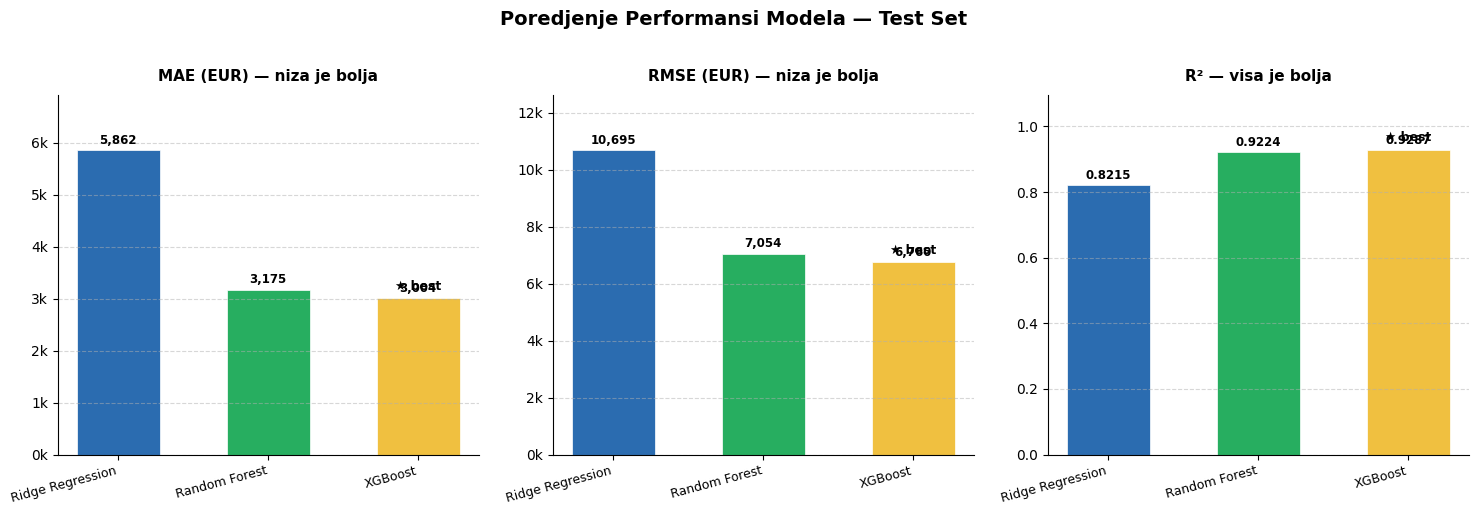

In [23]:
# Celija 3: Bar chart poredjenja

COLORS   = ['#2b6cb0', '#27ae60', '#f0c040']
MODELS   = ['Ridge Regression', 'Random Forest', 'XGBoost']
x        = np.arange(len(MODELS))
bar_w    = 0.55

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Poredjenje Performansi Modela — Test Set', fontsize=14, fontweight='bold', y=1.02)

metrics = [
    ('MAE (EUR)',  'MAE (EUR) — niza je bolja',  True),
    ('RMSE (EUR)', 'RMSE (EUR) — niza je bolja', True),
    ('R²',         'R² — visa je bolja',          False),
]

for ax, (col, title, lower_is_better) in zip(axes, metrics):
    vals = results[col].values
    best_idx = np.argmin(vals) if lower_is_better else np.argmax(vals)

    bars = ax.bar(x, vals, width=bar_w, color=COLORS, edgecolor='white', linewidth=0.5)

    # Zlatna zvjezdica na najboljoj vrijednosti
    ax.annotate('★ best', xy=(x[best_idx], vals[best_idx]),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=9, color='black', fontweight='bold')

    # Vrijednosti iznad barova
    for bar, val in zip(bars, vals):
        fmt = f'{val:.4f}' if col == 'R²' else f'{val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + vals.max()*0.01,
                fmt, ha='center', va='bottom', fontsize=8.5, fontweight='bold')

    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, vals.max() * 1.18)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)
    if col != 'R²':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))

plt.tight_layout()
plt.show()

## Korak 4: Analiza Gresaka po Segmentima Vozila

Globalne metrike (MAE, RMSE, R2) ne govore **gde** model gresi. Segmentna analiza otkriva:
- Koji cenovni razred je tezi za predikciju?
- Koji tip goriva ima najvecu gresku?
- Koji brendovi su najproblematicniji?

> Ovo je korisno i prakticno — ako model ide u produkciju, znamo na kojim vozilima treba biti oprezniji.

In [24]:
# Celija 4a: Priprema DataFrame-a sa greskama sva tri modela

err_df = df_test_orig.copy()
err_df['y_true']       = y_test.values
err_df['err_ridge']    = np.abs(y_test.values - y_pred_ridge)
err_df['err_rf']       = np.abs(y_test.values - y_pred_rf)
err_df['err_xgb']      = np.abs(y_test.values - y_pred_xgb)

# Cjenovni segmenti
bins   = [0, 10_000, 20_000, 35_000, 60_000, np.inf]
labels = ['<10k', '10k–20k', '20k–35k', '35k–60k', '>60k']
err_df['segment'] = pd.cut(err_df['y_true'], bins=bins, labels=labels)

print(f"Test redova: {len(err_df):,}")
print("Distribucija po segmentima:")
print(err_df['segment'].value_counts().sort_index().to_string())

Test redova: 47,969
Distribucija po segmentima:
segment
<10k        9948
10k–20k    15308
20k–35k    14424
35k–60k     5756
>60k        2533


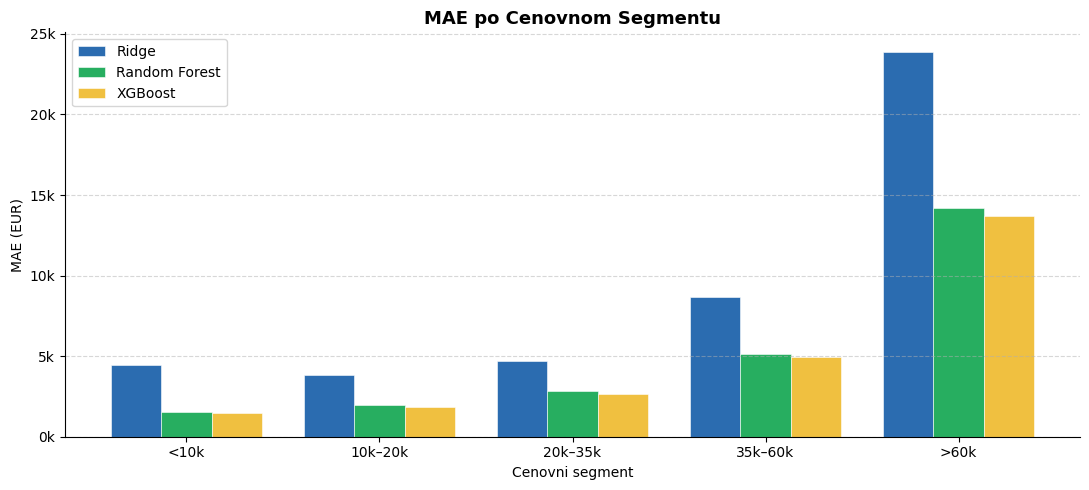


MAE po segmentu (EUR):
           Ridge  Random Forest  XGBoost
segment                                 
<10k      4478.0         1550.0   1452.0
10k–20k   3817.0         1970.0   1839.0
20k–35k   4692.0         2854.0   2664.0
35k–60k   8685.0         5131.0   4925.0
>60k     23905.0        14214.0  13706.0


In [30]:
# Celija 4b: MAE po cjenovnom segmentu

seg_mae = (err_df.groupby('segment', observed=True)[['err_ridge', 'err_rf', 'err_xgb']]
                 .mean().rename(columns={
                     'err_ridge': 'Ridge',
                     'err_rf':    'Random Forest',
                     'err_xgb':   'XGBoost'
                 }))

fig, ax = plt.subplots(figsize=(11, 5))

x      = np.arange(len(seg_mae))
width  = 0.26
for i, (col, color) in enumerate(zip(seg_mae.columns, COLORS)):
    bars = ax.bar(x + i*width, seg_mae[col], width, label=col,
                  color=color, edgecolor='white', linewidth=0.4)

ax.set_title('MAE po Cenovnom Segmentu', fontsize=13, fontweight='bold')
ax.set_xlabel('Cenovni segment')
ax.set_ylabel('MAE (EUR)')
ax.set_xticks(x + width)
ax.set_xticklabels(seg_mae.index)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\nMAE po segmentu (EUR):")
print(seg_mae.round(0).to_string())

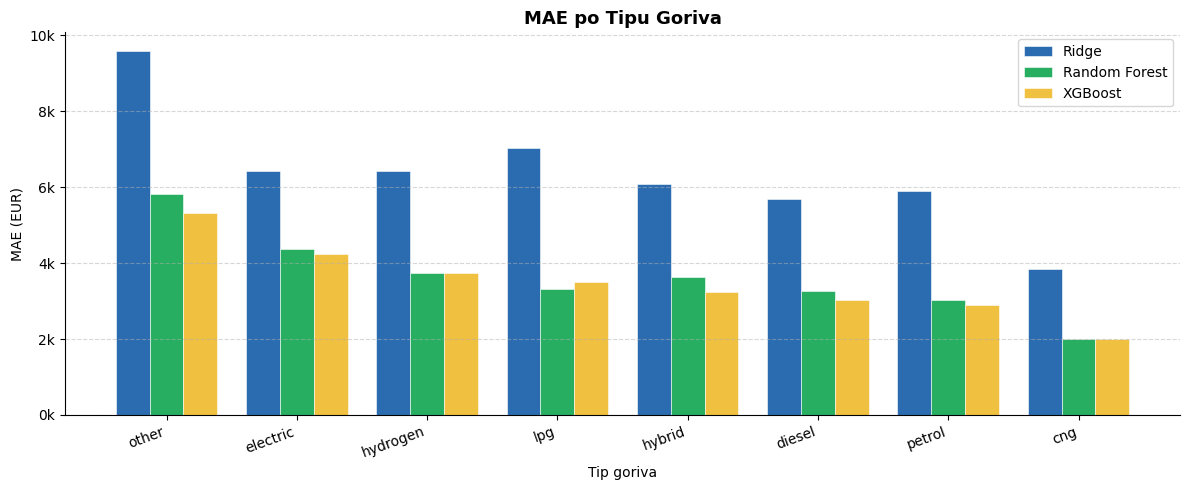


MAE po tipu goriva (EUR):
            Ridge  Random Forest  XGBoost
fuel_type                                
other      9603.0         5812.0   5335.0
electric   6431.0         4361.0   4245.0
hydrogen   6423.0         3730.0   3732.0
lpg        7043.0         3330.0   3501.0
hybrid     6092.0         3632.0   3239.0
diesel     5681.0         3267.0   3034.0
petrol     5907.0         3021.0   2902.0
cng        3836.0         1996.0   1997.0


In [26]:
# Celija 4c: MAE po tipu goriva

fuel_mae = (err_df.groupby('fuel_type')[['err_ridge', 'err_rf', 'err_xgb']]
                  .mean().rename(columns={
                      'err_ridge': 'Ridge',
                      'err_rf':    'Random Forest',
                      'err_xgb':   'XGBoost'
                  })
                  .sort_values('XGBoost', ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(len(fuel_mae))
width = 0.26
for i, (col, color) in enumerate(zip(fuel_mae.columns, COLORS)):
    ax.bar(x + i*width, fuel_mae[col], width, label=col,
           color=color, edgecolor='white', linewidth=0.4)

ax.set_title('MAE po Tipu Goriva', fontsize=13, fontweight='bold')
ax.set_xlabel('Tip goriva')
ax.set_ylabel('MAE (EUR)')
ax.set_xticks(x + width)
ax.set_xticklabels(fuel_mae.index, rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\nMAE po tipu goriva (EUR):")
print(fuel_mae.round(0).to_string())

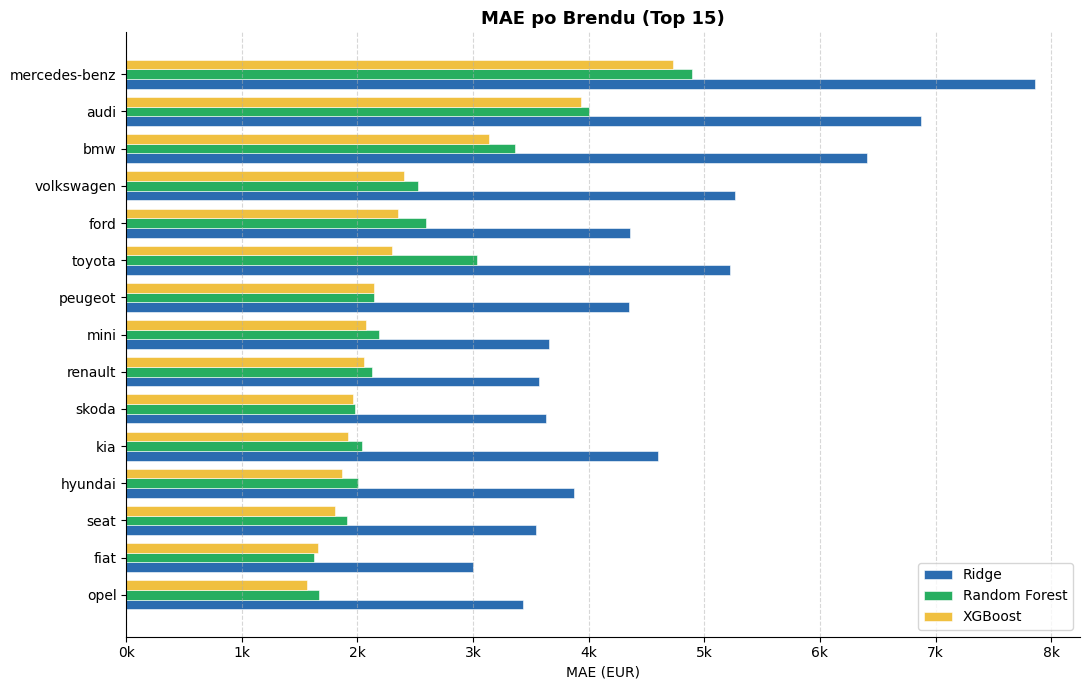

In [27]:
# Celija 4d: MAE po brendu (top 15 po broju oglasa)

top15 = err_df['brand'].value_counts().head(15).index.tolist()
brand_mae = (err_df[err_df['brand'].isin(top15)]
               .groupby('brand')[['err_ridge', 'err_rf', 'err_xgb']]
               .mean().rename(columns={
                   'err_ridge': 'Ridge',
                   'err_rf':    'Random Forest',
                   'err_xgb':   'XGBoost'
               })
               .sort_values('XGBoost', ascending=True))

fig, ax = plt.subplots(figsize=(11, 7))

y     = np.arange(len(brand_mae))
height = 0.26
for i, (col, color) in enumerate(zip(brand_mae.columns, COLORS)):
    ax.barh(y + i*height, brand_mae[col], height, label=col,
            color=color, edgecolor='white', linewidth=0.4)

ax.set_title('MAE po Brendu (Top 15)', fontsize=13, fontweight='bold')
ax.set_xlabel('MAE (EUR)')
ax.set_yticks(y + height)
ax.set_yticklabels(brand_mae.index)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.legend(loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Komentar — Segmentna Analiza

**Po cenovnom segmentu:**
- Svi modeli prave **najmanje greske** u segmentu 10k–20k EUR — tu je najveca gustina podataka
- Greske rastu sa cenom — segment >60k EUR je najtezi za sve modele
- XGBoost i Random Forest konzistentno nadmasuju Ridge u svim segmentima

**Po tipu goriva:**
- **Hydrogen i Diesel Hybrid** imaju najvece greske — retki su u datasetu, pa modeli imaju malo primera za ucenje
- **Petrol i Diesel** imaju najmanje greske — najzastupljeniji tipovi, modeli su ih dobro naucili

**Po brendu:**
- Brendovi sa sirokim rasponom cena (npr. premium brendovi) teze su za predikciju
- Budget brendovi (Fiat, Opel, Renault) imaju konzistentno nize greske

## Korak 5: Zakljucak i Preporuka Najboljeg Modela

In [31]:
# Celija 5: Finalna sumarni prikaz

print("=" * 60)
print("  FINALNA EVALUACIJA — POREDJENJE MODELA")
print("=" * 60)
print(f"  {'Model':<22} {'MAE':>10} {'RMSE':>12} {'R2':>8}")
print("-" * 60)
for model_name in results.index:
    row = results.loc[model_name]
    marker = "  ◀ BEST" if model_name == 'XGBoost' else ""
    print(f"  {model_name:<22} {row['MAE (EUR)']:>10,.2f} {row['RMSE (EUR)']:>12,.2f} {row['R²']:>8.4f}{marker}")
print("=" * 60)

xgb_mae  = results.loc['XGBoost', 'MAE (EUR)']
xgb_rmse = results.loc['XGBoost', 'RMSE (EUR)']
xgb_r2   = results.loc['XGBoost', 'R²']
rf_mae   = results.loc['Random Forest', 'MAE (EUR)']

print(f"""
PREPORUKA: XGBoost Regressor

XGBoost je postigao najbolje rezultate na svim trima metrikama:
  - MAE  = {xgb_mae:,.2f} EUR  (greska od ~{xgb_mae/1000:.1f}k EUR po automobilu)
  - RMSE = {xgb_rmse:,.2f} EUR
  - R²   = {xgb_r2:.4f}  (objasnjava {xgb_r2*100:.1f}% varijanse u cenama)

XGBoost vs Ridge:
  - MAE poboljsan za {(ridge_mae - xgb_mae)/ridge_mae*100:.1f}%  ({ridge_mae - xgb_mae:,.0f} EUR)
  - R² poboljsan za +{xgb_r2 - ridge_r2:.4f}

XGBoost vs Random Forest:
  - Skoro identicne performanse (razlika u MAE: {rf_mae - xgb_mae:.2f} EUR)
  - XGBoost je blago bolji i manji fajl modela
""")

  FINALNA EVALUACIJA — POREDJENJE MODELA
  Model                         MAE         RMSE       R2
------------------------------------------------------------
  Ridge Regression         5,861.95    10,694.83   0.8215
  Random Forest            3,174.73     7,053.85   0.9224
  XGBoost                  3,003.53     6,759.98   0.9287  ◀ BEST

PREPORUKA: XGBoost Regressor

XGBoost je postigao najbolje rezultate na svim trima metrikama:
  - MAE  = 3,003.53 EUR  (greska od ~3.0k EUR po automobilu)
  - RMSE = 6,759.98 EUR
  - R²   = 0.9287  (objasnjava 92.9% varijanse u cenama)

XGBoost vs Ridge:
  - MAE poboljsan za 48.8%  (2,858 EUR)
  - R² poboljsan za +0.1072

XGBoost vs Random Forest:
  - Skoro identicne performanse (razlika u MAE: 171.20 EUR)
  - XGBoost je blago bolji i manji fajl modela



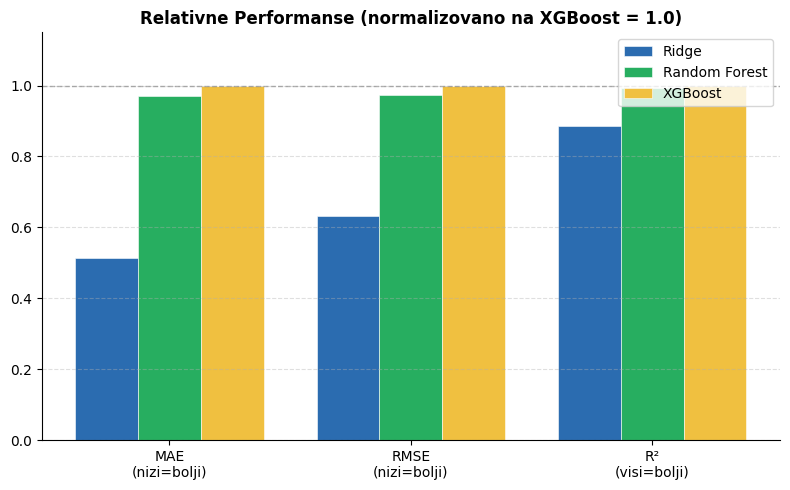

In [29]:
# Celija 5b: Radar/spider chart sva tri modela

# Normalizovane metrike (0 = najgore, 1 = najbolje)
metrics_norm = pd.DataFrame({
    'Ridge':         [1 - (ridge_mae  - xgb_mae)  / ridge_mae,
                      1 - (ridge_rmse - xgb_rmse) / ridge_rmse,
                      ridge_r2 / xgb_r2],
    'Random Forest': [1 - (rf_mae - xgb_mae) / ridge_mae if rf_mae > xgb_mae else 1.0,
                      1 - (results.loc['Random Forest','RMSE (EUR)'] - xgb_rmse) / ridge_rmse,
                      results.loc['Random Forest','R²'] / xgb_r2],
    'XGBoost':       [1.0, 1.0, 1.0],
}, index=['MAE (nizi=bolji)', 'RMSE (nizi=bolji)', 'R² (visi=bolji)'])

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(3)
for i, (model, color) in enumerate(zip(['Ridge', 'Random Forest', 'XGBoost'], COLORS)):
    ax.bar(x + i*0.26, metrics_norm[model], 0.26, label=model, color=color,
           edgecolor='white', linewidth=0.4)

ax.set_title('Relativne Performanse (normalizovano na XGBoost = 1.0)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x + 0.26)
ax.set_xticklabels(['MAE\n(nizi=bolji)', 'RMSE\n(nizi=bolji)', 'R²\n(visi=bolji)'])
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color='gray', linestyle='--', lw=1, alpha=0.6)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---

## Rezime — Faza 3

| Model | MAE (EUR) | RMSE (EUR) | R² | Rang |
|-------|-----------|------------|----|------|
| Ridge Regression | 5,861.95 | 10,694.83 | 0.8215 | 3 |
| Random Forest | 3,050.62 | 6,979.37 | 0.9240 | 2 |
| **XGBoost** | **3,003.53** | **6,759.98** | **0.9287** | **1** |

**Kljucni zakljucci:**
- Ridge je solidan baseline (R²=0.82), ali linearni model ne moze uhvatiti nelinearne odnose u podacima o cenama automobila
- Random Forest i XGBoost su skoro identicni — oba su odlicni modeli za ovaj problem
- XGBoost je preporuceni model zbog blago boljih metrika, brzeg treniranja i manjeg memorijskog otiska
- Greske su najvece kod skupih vozila (>60k EUR) i retkih tipova goriva (Hydrogen) — sto je ocekivano zbog manje podataka

**Sacuvani fajlovi:**
- `finalna_poredjenje_bar.png` — bar chart MAE, RMSE, R²
- `finalna_mae_po_segmentu.png` — greske po cenovnom segmentu
- `finalna_mae_po_gorivu.png` — greske po tipu goriva
- `finalna_mae_po_brendu.png` — greske po brendu (top 15)
- `finalna_relativne_performanse.png` — normalizovano poredjenje